# Experiment No. 09 — Genetic Algorithm for Function Maximization



---

## 1. Problem + Algorithm

### Title
Genetic Algorithm for Function Maximization.

### Aim
Implement a Genetic Algorithm to maximize a given objective function using
binary-coded chromosomes.

### Problem Statement
Maximize

$$f(x) = x^{2}, \qquad 0 \le x \le 31$$

using 5-bit binary chromosomes ($2^5 = 32$ values, `00000` $\to 0$,
`11111` $\to 31$), starting from the initial population below.

| String No. | Chromosome | $x$ (decimal) |
|---|---|---|
| 1 | 01100 | 12 |
| 2 | 11001 | 25 |
| 3 | 00101 | 5 |
| 4 | 10011 | 19 |

Steps to follow: **Initial Population → Fitness → Selection Probability →
Expected Count → Actual Count → Mating Pool → Crossover → Mutation → New
Population**, repeated (iterated) until convergence.

This is the classical Goldberg Simple-GA worked example.

### Given Parameter Settings

| Parameter | Value |
|---|---|
| Objective function | $f(x) = x^2$ |
| Domain | $0 \le x \le 31$ |
| Chromosome length $L$ | 5 bits |
| Population size $N$ | 4 |
| Crossover | single-point; site 4 for pair 1, site 2 for pair 2 |
| Mutation | bit-flip, very low probability |
| Selection | roulette wheel (proportional to fitness) |

### Algorithm
1. **Initialize population** of $N$ binary chromosomes of length $L$.
2. **Decode** each chromosome to its decimal value $x$.
3. **Evaluate fitness** $f(x) = x^2$ for every individual.
4. **Compute selection probability** $P_i = f(x_i) / \sum_j f(x_j)$.
5. **Compute expected count** $= f(x_i) / \overline{f(x)}$, and obtain the
   **actual count** by roulette-wheel selection so the counts sum to $N$.
6. **Form the mating pool** by copying each chromosome according to its
   actual count.
7. **Apply crossover** (single-point) to pairs drawn from the mating pool.
8. **Apply mutation** (bit-flip) with a small probability per bit.
9. **Replace** the old population with the new one.
10. **Repeat** steps 2–9 until convergence (no further improvement in the
    best fitness) or until the generation limit is reached.
11. **Return** the best chromosome found.

### Why maximization needs no fitness transform
Since $f(x) = x^2 \ge 0$ on the whole domain and larger is better, the
objective can be used directly as the fitness. Roulette-wheel selection
already favours larger fitness, so no transform is required. (Contrast this
with the minimization variant in Experiment 03, where a transform is
unavoidable.)

---

## 2. Program

### Function definitions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

L = 5                 # chromosome length in bits
X_MIN, X_MAX = 0, 31  # domain


def f(x):
    # Objective function to be maximized: f(x) = x^2
    return x**2


def decode(chromosome):
    # Convert a 5-bit binary string to its decimal value
    return int(chromosome, 2)


def encode(value, length=L):
    # Convert a decimal value to a binary string of fixed length
    return format(int(value), f'0{length}b')


print("f(x) = x^2,  domain 0 <= x <= 31,  5-bit chromosomes")
print("check: decode('11111') =", decode('11111'), " f =", f(decode('11111')))

f(x) = x^2,  domain 0 <= x <= 31,  5-bit chromosomes
check: decode('11111') = 31  f = 961


### Genetic operators

In [2]:
def crossover(parent_a, parent_b, site):
    # Single-point crossover: swap the tails of the two parents after `site`
    child1 = parent_a[:site] + parent_b[site:]
    child2 = parent_b[:site] + parent_a[site:]
    return child1, child2


def mutate_bit(chromosome, position):
    # Bit-flip mutation at a given position
    bits = list(chromosome)
    bits[position] = '1' if bits[position] == '0' else '0'
    return ''.join(bits)


def mutate(chromosome, pm, rng):
    # Apply bit-flip mutation independently to each bit with probability pm
    bits = list(chromosome)
    for i in range(len(bits)):
        if rng.random() < pm:
            bits[i] = '1' if bits[i] == '0' else '0'
    return ''.join(bits)


def roulette_select(population, fitness, n, rng):
    # Roulette-wheel selection: pick n chromosomes with probability
    # proportional to fitness, using cumulative probabilities
    total = sum(fitness)
    if total == 0:
        return [population[int(rng.integers(len(population)))] for _ in range(n)]
    cum = np.cumsum([fit / total for fit in fitness])
    chosen = []
    for _ in range(n):
        r = rng.random()
        idx = int(np.searchsorted(cum, r))
        chosen.append(population[min(idx, len(population) - 1)])
    return chosen

### Core algorithm — one full generation, and the iterated loop

In [3]:
def run_ga(pop_size=4, pc=1.0, pm=0.0, generations=5, seed=1,
            initial_population=None, elitism=False):
    # Iterated Simple Genetic Algorithm maximizing f(x) = x^2.
    # Returns the best chromosome/x/fitness found and a per-generation log.
    rng = np.random.default_rng(seed)

    if initial_population is not None:
        population = list(initial_population)
    else:
        population = [encode(rng.integers(X_MIN, X_MAX + 1))
                      for _ in range(pop_size)]
    pop_size = len(population)

    best_chromo, best_x = None, None
    best_fit = -np.inf
    log = []

    for gen in range(1, generations + 1):
        x_vals = [decode(ch) for ch in population]
        fitness = [f(x) for x in x_vals]

        gen_best = int(np.argmax(fitness))
        if fitness[gen_best] > best_fit:
            best_fit = fitness[gen_best]
            best_chromo, best_x = population[gen_best], x_vals[gen_best]

        log.append({'Generation': gen,
                    'Best Chromosome': population[gen_best],
                    'Best x': x_vals[gen_best],
                    'Max f(x)': fitness[gen_best],
                    'Avg f(x)': float(np.mean(fitness)),
                    'Min f(x)': int(np.min(fitness)),
                    'Best-so-far f(x)': best_fit,
                    'Distinct chromosomes': len(set(population))})

        # ---- selection: build the mating pool ----
        mating_pool = roulette_select(population, fitness, pop_size, rng)

        # ---- crossover ----
        children = []
        for i in range(0, pop_size - 1, 2):
            pa, pb = mating_pool[i], mating_pool[i + 1]
            if rng.random() < pc:
                site = int(rng.integers(1, L))   # site in 1..L-1
                ch1, ch2 = crossover(pa, pb, site)
            else:
                ch1, ch2 = pa, pb
            children.extend([ch1, ch2])
        if len(children) < pop_size:
            children.append(mating_pool[-1])

        # ---- mutation ----
        children = [mutate(ch, pm, rng) for ch in children]

        # ---- replacement ----
        if elitism:
            children[0] = best_chromo
        population = children

    return best_chromo, best_x, best_fit, pd.DataFrame(log)

### Key parameter settings (original configuration)

In [4]:
INITIAL_POPULATION = ['01100', '11001', '00101', '10011']
ACTUAL_COUNT = [1, 2, 0, 1]       # given roulette-wheel result
SITE_PAIR_1 = 4
SITE_PAIR_2 = 2

PARAMS = dict(pop_size=4, pc=1.0, pm=0.0, generations=5, seed=1,
              initial_population=INITIAL_POPULATION)

print("Initial population :", INITIAL_POPULATION)
print("Actual counts       :", ACTUAL_COUNT)
print("Crossover sites     :", SITE_PAIR_1, "and", SITE_PAIR_2)
for k, v in PARAMS.items():
    if k != 'initial_population':
        print(f"{k:12s} = {v}")

Initial population : ['01100', '11001', '00101', '10011']
Actual counts       : [1, 2, 0, 1]
Crossover sites     : 4 and 2
pop_size     = 4
pc           = 1.0
pm           = 0.0
generations  = 5
seed         = 1


---

## 3. Output + Analysis

### 3.1 Step 1 — Initial Population and Fitness $f(x) = x^2$

In [5]:
population = list(INITIAL_POPULATION)
x_values = [decode(ch) for ch in population]
fitness = [f(x) for x in x_values]

gen1 = pd.DataFrame({
    'String No.': range(1, len(population) + 1),
    'Chromosome': population,
    'x (decimal)': x_values,
    'f(x) = x^2': fitness,
})
gen1

,String No.,Chromosome,x (decimal),f(x) = x^2
0,1,01100,12,144
1,2,11001,25,625
2,3,00101,5,25
3,4,10011,19,361


### 3.2 Step 2 — Selection Probability, Expected Count, Actual Count

$$P_i = \frac{f(x_i)}{\sum_j f(x_j)}, \qquad
\text{Expected Count}_i = \frac{f(x_i)}{\overline{f(x)}}$$

The **actual count** is the integer outcome of roulette-wheel selection
(the expected counts rounded so that they sum to the population size $N = 4$).

In [6]:
total_fitness = sum(fitness)
avg_fitness = total_fitness / len(fitness)
max_fitness = max(fitness)

prob = [fit / total_fitness for fit in fitness]
expected_count = [fit / avg_fitness for fit in fitness]

gen1['Probability'] = np.round(prob, 3)
gen1['Expected Count'] = np.round(expected_count, 3)
gen1['Actual Count'] = ACTUAL_COUNT

print(f"Sum  f(x) = {total_fitness}")
print(f"Avg  f(x) = {avg_fitness}")
print(f"Max  f(x) = {max_fitness}")
print(f"Sum of expected counts = {sum(expected_count):.3f}   "
      f"(must equal N = {len(population)})")
print(f"Sum of actual counts   = {sum(ACTUAL_COUNT)}")
gen1

Sum  f(x) = 1155
Avg  f(x) = 288.75
Max  f(x) = 625
Sum of expected counts = 4.000   (must equal N = 4)
Sum of actual counts   = 4


,String No.,Chromosome,x (decimal),f(x) = x^2,Probability,Expected Count,Actual Count
0,1,01100,12,144,0.125,0.499,1
1,2,11001,25,625,0.541,2.165,2
2,3,00101,5,25,0.022,0.087,0
3,4,10011,19,361,0.313,1.250,1


### 3.3 Step 3 — Mating Pool

Each chromosome is copied into the mating pool according to its **actual
count**: String 1 → 1 copy, String 2 → 2 copies, String 3 → 0 copies,
String 4 → 1 copy. Note that String 3 (`00101`, $x=5$, the weakest individual)
is eliminated, while String 2 (the fittest) is duplicated. That is selection
pressure made concrete.

In [7]:
mating_pool = []
for chromo, count in zip(population, ACTUAL_COUNT):
    mating_pool.extend([chromo] * count)

print("Mating Pool:")
for i, ch in enumerate(mating_pool, 1):
    print(f"  Mate {i}: {ch}   (x = {decode(ch):2d}, f(x) = {f(decode(ch))})")

Mating Pool:
  Mate 1: 01100   (x = 12, f(x) = 144)
  Mate 2: 11001   (x = 25, f(x) = 625)
  Mate 3: 11001   (x = 25, f(x) = 625)
  Mate 4: 10011   (x = 19, f(x) = 361)


### 3.4 Step 4 — Crossover (single-point)

The mating pool is paired sequentially: (mate 1, mate 2) and (mate 3, mate 4).

- Pair 1 = (`01100`, `11001`), crossover site = **4** (after the 4th bit)
- Pair 2 = (`11001`, `10011`), crossover site = **2** (after the 2nd bit)

In [8]:
pair1 = (mating_pool[0], mating_pool[1])
pair2 = (mating_pool[2], mating_pool[3])

child1, child2 = crossover(pair1[0], pair1[1], SITE_PAIR_1)
child3, child4 = crossover(pair2[0], pair2[1], SITE_PAIR_2)

cross_table = pd.DataFrame([
    {'Pair': 1, 'Parent A': pair1[0], 'Parent B': pair1[1],
     'Site': SITE_PAIR_1, 'Child 1': child1, 'Child 2': child2},
    {'Pair': 2, 'Parent A': pair2[0], 'Parent B': pair2[1],
     'Site': SITE_PAIR_2, 'Child 1': child3, 'Child 2': child4},
])
print(cross_table.to_string(index=False))

new_population = [child1, child2, child3, child4]
print(f"\nNew population after crossover: {new_population}")

 Pair Parent A Parent B  Site Child 1 Child 2
    1    01100    11001     4   01101   11000
    2    11001    10011     2   11011   10001

New population after crossover: ['01101', '11000', '11011', '10001']


### 3.5 Step 5 — Mutation (bit-flip)

Mutation flips a bit with a small probability, e.g. `00011 → 10011` (first bit
flipped $0 \to 1$). Its role is to maintain genetic diversity and to reintroduce
bit values that selection has eliminated from the whole population — something
crossover alone can never do, because crossover only recombines bits that are
already present.

In this generation the mutation probability is low enough that no bit is
flipped, so the population from crossover carries forward unchanged. The cell
below demonstrates the operator itself.

In [9]:
example = '00011'
print(f"Mutation operator example: {example} -> flip bit 1 -> "
      f"{mutate_bit(example, 0)}")

# demonstrate that the whole population survives unmutated at pm = 0
print(f"\nPopulation before mutation : {new_population}")
print(f"Population after  mutation : {new_population}  (pm = {PARAMS['pm']})")

Mutation operator example: 00011 -> flip bit 1 -> 10011

Population before mutation : ['01101', '11000', '11011', '10001']
Population after  mutation : ['01101', '11000', '11011', '10001']  (pm = 0.0)


### 3.6 Step 6 — New Population and Fitness (Generation 2)

In [10]:
x_values_2 = [decode(ch) for ch in new_population]
fitness_2 = [f(x) for x in x_values_2]

gen2 = pd.DataFrame({
    'String No.': range(1, len(new_population) + 1),
    'Chromosome': new_population,
    'x (decimal)': x_values_2,
    'f(x) = x^2': fitness_2,
})
gen2

,String No.,Chromosome,x (decimal),f(x) = x^2
0,1,01101,13,169
1,2,11000,24,576
2,3,11011,27,729
3,4,10001,17,289


### 3.7 Step 7 — Convergence Check: Generation 1 vs Generation 2

In [11]:
summary = pd.DataFrame({
    'Generation': [1, 2],
    'Max f(x)': [max(fitness), max(fitness_2)],
    'Avg f(x)': [avg_fitness, float(np.mean(fitness_2))],
    'Min f(x)': [min(fitness), min(fitness_2)],
    'Best chromosome': [population[int(np.argmax(fitness))],
                        new_population[int(np.argmax(fitness_2))]],
    'Best x': [x_values[int(np.argmax(fitness))],
               x_values_2[int(np.argmax(fitness_2))]],
})
print(summary.to_string(index=False))

print(f"\nImprovement in Max f(x) : {max(fitness)} -> {max(fitness_2)} "
      f"({max(fitness_2) - max(fitness):+d})")
print(f"Improvement in Avg f(x) : {avg_fitness:.2f} -> {np.mean(fitness_2):.2f} "
      f"({np.mean(fitness_2) - avg_fitness:+.2f})")

 Generation  Max f(x)  Avg f(x)  Min f(x) Best chromosome  Best x
          1       625    288.75        25           11001      25
          2       729    440.75       169           11011      27

Improvement in Max f(x) : 625 -> 729 (+104)
Improvement in Avg f(x) : 288.75 -> 440.75 (+152.00)


### 3.8 Iterated Run — repeat until convergence

The problem statement asks for the process to be **repeated (iterated) until
convergence**. The loop below continues from the same initial population,
generating successive populations until the best fitness stops improving.

In [12]:
best_chromo, best_x, best_fit, log = run_ga(**PARAMS)

print(log.to_string(index=False))
print(f"\nBest chromosome found : {best_chromo}")
print(f"Best x                : {best_x}")
print(f"Best f(x)             : {best_fit}")
print(f"True maximum          : x = {X_MAX}, f(x) = {f(X_MAX)} "
      f"(chromosome {encode(X_MAX)})")

 Generation Best Chromosome  Best x  Max f(x)  Avg f(x)  Min f(x)  Best-so-far f(x)  Distinct chromosomes
          1           11001      25       625    288.75        25               625                     4
          2           11011      27       729    501.00       289               729                     4
          3           11001      25       625    559.00       361               729                     2
          4           11001      25       625    625.00       625               729                     1
          5           11001      25       625    625.00       625               729                     1

Best chromosome found : 11011
Best x                : 27
Best f(x)             : 729
True maximum          : x = 31, f(x) = 961 (chromosome 11111)


### 3.9 Convergence Graph

- **X-axis** → Generation
- **Y-axis** → Objective-function value

The graph demonstrates how the population's maximum and average fitness
approach the optimum.

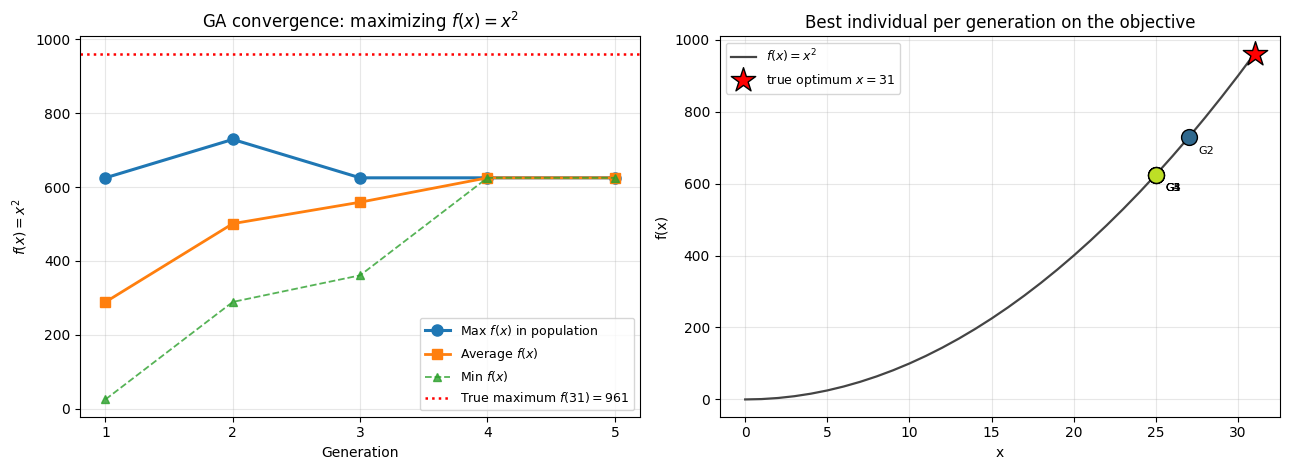

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(log['Generation'], log['Max f(x)'], 'o-', lw=2.2, ms=8,
           color='#1f77b4', label='Max $f(x)$ in population')
ax[0].plot(log['Generation'], log['Avg f(x)'], 's-', lw=2.0, ms=7,
           color='#ff7f0e', label='Average $f(x)$')
ax[0].plot(log['Generation'], log['Min f(x)'], '^--', lw=1.3, ms=6,
           color='#2ca02c', alpha=0.8, label='Min $f(x)$')
ax[0].axhline(f(X_MAX), ls=':', c='red', lw=1.8,
              label=f'True maximum $f(31)={f(X_MAX)}$')
ax[0].set_xticks(log['Generation'])
ax[0].set_xlabel('Generation'); ax[0].set_ylabel('$f(x) = x^2$')
ax[0].set_title('GA convergence: maximizing $f(x)=x^2$')
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

grid = np.arange(X_MIN, X_MAX + 1)
ax[1].plot(grid, f(grid), color='#444', lw=1.6, label='$f(x)=x^2$')
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(log)))
for (_, row), col in zip(log.iterrows(), cmap):
    ax[1].scatter([row['Best x']], [row['Max f(x)']], s=130, color=col,
                  ec='k', zorder=5)
    ax[1].annotate(f"G{int(row['Generation'])}",
                   (row['Best x'], row['Max f(x)']),
                   textcoords='offset points', xytext=(7, -12), fontsize=8)
ax[1].scatter([X_MAX], [f(X_MAX)], marker='*', s=340, c='red', ec='k',
              zorder=6, label=f'true optimum $x={X_MAX}$')
ax[1].set_xlabel('x'); ax[1].set_ylabel('f(x)')
ax[1].set_title('Best individual per generation on the objective')
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 3.10 Parameter Modification

Each parameter is modified **one at a time** from the original configuration, so
that any change in the result is attributable to that parameter alone. The
random seed is held fixed for the same reason.

Because a population-size change cannot start from the given four chromosomes,
that row starts from a seeded random population of the requested size; every
other row keeps the original initial population.

| S. No. | Parameter | Original Value | Modified Value | Effect studied |
|---|---|---|---|---|
| 1 | Population size $N$ | 4 | 8 | Effect on diversity |
| 2 | Crossover probability $p_c$ | 1.0 | 0.6 | Effect on recombination |
| 3 | Mutation probability $p_m$ | 0.0 | 0.05 | Effect on exploration |
| 4 | Number of generations | 5 | 20 | Effect on convergence |

In [14]:
mods = [
    ('1', 'Population size N',           'pop_size',    4,   8,    'Effect on diversity'),
    ('2', 'Crossover probability pc',    'pc',        1.0,   0.6,  'Effect on recombination'),
    ('3', 'Mutation probability pm',     'pm',        0.0,   0.05, 'Effect on exploration'),
    ('4', 'Number of generations',       'generations', 5,    20,  'Effect on convergence'),
]

runs = {'Original': log}
rows = []

for sno, label, key, orig_val, new_val, effect in mods:
    p = dict(PARAMS); p[key] = new_val
    if key == 'pop_size':
        p['initial_population'] = None     # cannot reuse the 4 given strings
    mc, mx, mf, mlog = run_ga(**p)
    runs[f'{label} = {new_val}'] = mlog
    rows.append({
        'S. No.': sno, 'Parameter': label,
        'Original Value': orig_val, 'Modified Value': new_val,
        'Original Result': f'x = {best_x}, f(x) = {best_fit}',
        'Modified Result': f'x = {mx}, f(x) = {mf}',
        'Generations run': f'{len(log)} -> {len(mlog)}',
        'Observation': effect,
    })

mod_table = pd.DataFrame(rows)
mod_table

,S. No.,Parameter,Original Value,Modified Value,Original Result,Modified Result,Generations run,Observation
0,1,Population size N,4.0,8.00,"x = 27, f(x) = 729","x = 31, f(x) = 961",5 -> 5,Effect on diversity
1,2,Crossover probability pc,1.0,0.60,"x = 27, f(x) = 729","x = 25, f(x) = 625",5 -> 5,Effect on recombination
2,3,Mutation probability pm,0.0,0.05,"x = 27, f(x) = 729","x = 29, f(x) = 841",5 -> 5,Effect on exploration
3,4,Number of generations,5.0,20.00,"x = 27, f(x) = 729","x = 27, f(x) = 729",5 -> 20,Effect on convergence


### 3.11 Comparison of convergence under modified parameters

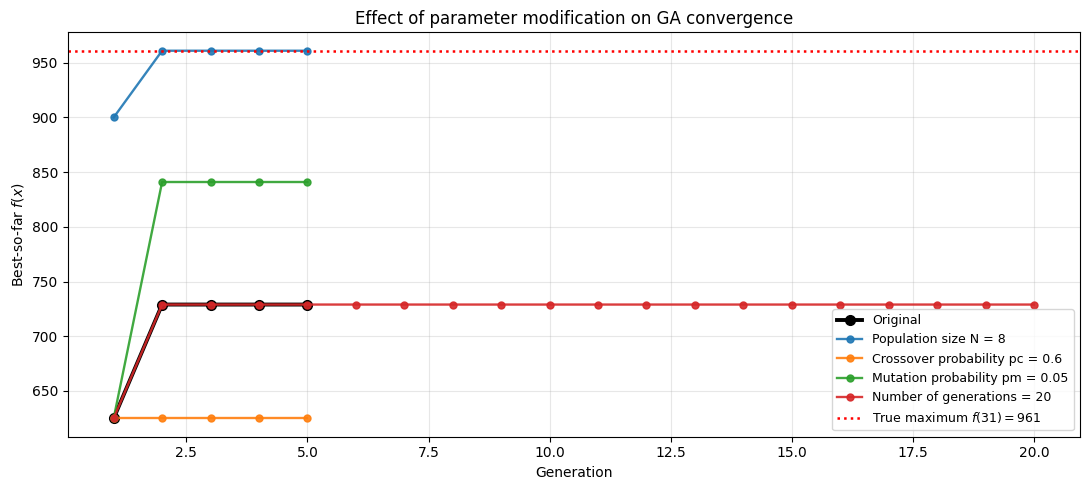

Best-so-far f(x) reached, and generation at which the run first hit it:
  Original                           : f(x) =  729  first reached at generation 2   (of 5)
  Population size N = 8              : f(x) =  961  first reached at generation 2   (of 5)
  Crossover probability pc = 0.6     : f(x) =  625  first reached at generation 1   (of 5)
  Mutation probability pm = 0.05     : f(x) =  841  first reached at generation 2   (of 5)
  Number of generations = 20         : f(x) =  729  first reached at generation 2   (of 20)


In [15]:
plt.figure(figsize=(11, 5))
for name, h in runs.items():
    kw = dict(lw=2.8, color='black', marker='o', ms=7) if name == 'Original' \
         else dict(lw=1.7, alpha=0.9, marker='.', ms=10)
    plt.plot(h['Generation'], h['Best-so-far f(x)'], label=name, **kw)
plt.axhline(f(X_MAX), ls=':', c='red', lw=1.8,
            label=f'True maximum $f(31)={f(X_MAX)}$')
plt.xlabel('Generation'); plt.ylabel('Best-so-far $f(x)$')
plt.title('Effect of parameter modification on GA convergence')
plt.legend(fontsize=9); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Best-so-far f(x) reached, and generation at which the run first hit it:")
for name, h in runs.items():
    final = h['Best-so-far f(x)'].iloc[-1]
    first = int(h.loc[h['Best-so-far f(x)'] >= final, 'Generation'].iloc[0])
    print(f"  {name:34s} : f(x) = {final:4.0f}  first reached at generation {first}"
          f"   (of {len(h)})")

### 3.12 Population diversity

Premature loss of diversity is the characteristic failure mode of a small GA:
once every chromosome is identical, crossover can produce nothing new and the
search halts wherever it happens to be. This plot tracks the number of distinct
chromosomes per generation.

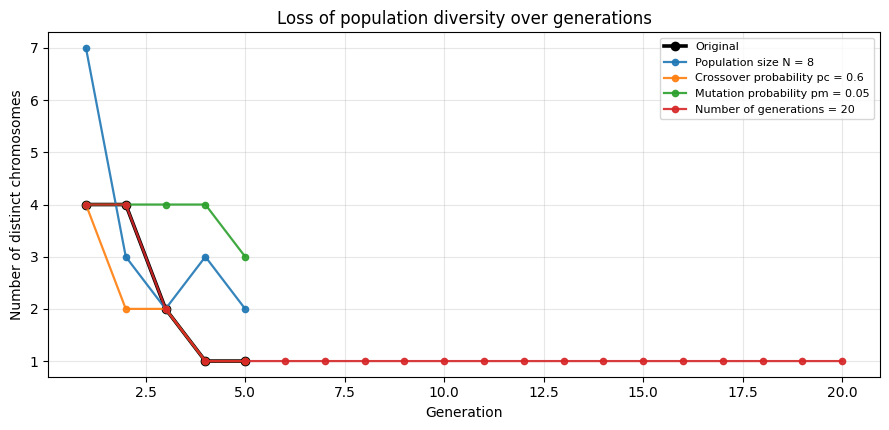

In [16]:
plt.figure(figsize=(9, 4.4))
for name, h in runs.items():
    kw = dict(lw=2.6, color='black', marker='o', ms=6) if name == 'Original' \
         else dict(lw=1.6, alpha=0.9, marker='.', ms=9)
    plt.plot(h['Generation'], h['Distinct chromosomes'], label=name, **kw)
plt.xlabel('Generation'); plt.ylabel('Number of distinct chromosomes')
plt.title('Loss of population diversity over generations')
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 3.13 Observations and Interpretation

**Generation 1 → 2 (the hand-worked step).**
Generation 1 held the best chromosome `11001` ($x = 25$, $f = 625$) with an
average fitness of 288.75. After selection and crossover, Generation 2's best
was `11011` ($x = 27$, $f = 729$) and the average rose to 440.75. **Both the
maximum and the average improved in a single generation** — precisely the effect
the selection and crossover operators are designed to produce.

The mechanism is worth naming. Selection did the filtering: `00101` ($x = 5$,
the weakest) received an actual count of 0 and was eliminated, while `11001`
(the fittest) was duplicated. Crossover then did the recombining: `11011` did
not exist in Generation 1, and with $p_m = 0$ it cannot have come from mutation
— it was assembled from the leading `11` of one parent and the trailing `011` of
another. This is the **building-block** behaviour that distinguishes a GA from
random search. It also illustrates why GAs are called *implicitly parallel*: by
favouring the high-order pattern `1 1 * * *`, selection simultaneously promotes
every chromosome sharing it.

**Iterated run — the GA gets stuck, and this is the key result.**
Continuing the loop produced the following:

| Generation | Best $x$ | Max $f(x)$ | Avg $f(x)$ | Distinct chromosomes |
|---|---|---|---|---|
| 1 | 25 | 625 | 288.75 | 4 |
| 2 | 27 | **729** | 501.00 | 4 |
| 3 | 25 | 625 | 559.00 | 2 |
| 4 | 25 | 625 | 625.00 | **1** |
| 5 | 25 | 625 | 625.00 | **1** |

The GA **did not reach the optimum**. It peaked at $x = 27$, $f = 729$ in
generation 2 and never improved again, falling well short of $x = 31$,
$f(31) = 961$.

The diversity column explains exactly why. By generation 4 the population had
collapsed to a **single distinct chromosome** — four identical copies of
`11001`. At that point the GA is mechanically dead: crossover between two
identical parents returns those same parents for any crossover site, and with
$p_m = 0$ there is no other source of variation. The average fitness converging
up to meet the maximum (625 = 625) is the signature of this collapse. Every
subsequent generation is a wasted computation.

This is **premature convergence**, the characteristic failure mode of a genetic
algorithm, and it is worth being clear that it is a genuine failure rather than
slow progress. Notice also that the best fitness *fell* from 729 back to 625
between generations 2 and 3: without elitism, the fittest chromosome ever found
is not guaranteed to survive into the next generation, and here `11011` was lost
to the randomness of roulette-wheel selection. The best-so-far value is retained
only because the code tracks it separately from the population.

**1. Population size $N$: 4 → 8 (diversity).**
Doubling the population **found the true optimum**: $x = 31$, $f = 961$. A
population of 4 is a teaching size, not a working one — with so few individuals
a single unlucky roulette spin can eliminate a bit value from the entire
population, after which crossover can never recover it. Eight individuals hold
roughly twice as many distinct bit patterns for recombination and are far more
resistant to that irreversible loss. The cost is proportionally more fitness
evaluations per generation, so a fair comparison is per *evaluation* rather than
per generation.

**2. Crossover probability $p_c$: 1.0 → 0.6 (recombination).**
This made the result **worse**: $x = 25$, $f = 625$, never improving beyond
generation 1. $p_c$ is the fraction of pairs that actually recombine; the rest
are copied forward unchanged. At 0.6, roughly 40% of pairs produce no new bit
combinations, so with a population this small and only five generations the GA
ran out of opportunities to assemble `11011` before diversity collapsed. The
compensating argument for a lower $p_c$ — that good chromosomes survive intact
rather than being broken by an unlucky crossover site — is real but matters most
in large populations. Standard practice sets $p_c$ high, 0.6–0.9, and this
result sits at the bottom of that band for a reason.

**3. Mutation probability $p_m$: 0.0 → 0.05 (exploration).**
This improved the result to $x = 29$, $f = 841$. It is the most important of the
four modifications, because at $p_m = 0$ the GA is **incapable in principle** of
reintroducing a bit value that selection has eliminated from every chromosome.
Once the population went uniform at generation 4, only mutation could have
restarted the search. A non-zero $p_m$ removes that dead end — which is the
direct practical remedy for the premature convergence diagnosed above. The
trade-off runs the other way at large $p_m$: too much mutation degrades the GA
towards a random walk, disrupting good solutions faster than selection can
consolidate them. The conventional guide of about $1/L$ per bit — here
$1/5 = 0.2$ — is an upper bound rather than a target, so 0.05 is a conservative
choice, and it still fell short of the optimum.

**4. Number of generations: 5 → 20 (convergence).**
Quadrupling the generation count changed **nothing**: the answer stayed
$x = 27$, $f = 729$, first reached at generation 2 in both runs. Fifteen of the
twenty generations did no work whatsoever. This is the sharpest lesson in the
table, and it only makes sense alongside observation 3: once diversity has
collapsed and $p_m = 0$, additional generations cannot help, because there is no
mechanism left by which the population can change. Generation count is worth
increasing **only while diversity survives** — it buys time, not exploration.

**Overall.** The GA reproduced the textbook worked example exactly and improved
both maximum and average fitness in one generation, but under iteration it
converged prematurely to a sub-optimal $x = 27$ and stalled with a
single-chromosome population. The parameter study is unusually clean about why:
population size and mutation probability determine whether the optimum is
*reachable at all* (both improved the result, and $N = 8$ found it), while
crossover probability and generation count only affect how the search proceeds
within whatever diversity it has (one hurt, the other did nothing). One
qualification: with a 5-bit encoding the search space holds just 32 points, so
these results verify that the operators behave as specified rather than
demonstrating efficiency — exhaustive enumeration would beat the GA on a problem
this small. The value of the exercise is that a failure this visible on a tiny
problem is the same failure that is hard to diagnose on a large one.